# 📱 Second-Hand Mobile Price Analyzer — Egypt (Dubizzle)

> **Project Goal:** Predict whether a used mobile phone listing is **Fair 🟡**, **Good Deal 🟢**, or **Overpriced 🔴** using image analysis via CNN and ViT models.

---

## 📋 Project Architecture

```
mobile_phones.csv  ──►  Data Loading & EDA
                              │
                    ┌─────────▼──────────┐
                    │  Image Downloader  │
                    └─────────┬──────────┘
                              │
              ┌───────────────▼───────────────┐
              │         Preprocessing          │
              │  (Price Label + Image Resize)  │
              └───────────────┬───────────────┘
                              │
           ┌──────────────────▼──────────────────┐
           │                                      │
      ┌────▼─────┐                        ┌──────▼──────┐
      │  CNN     │                        │  ViT        │
      │ (Custom) │                        │ (Pretrained)│
      └────┬─────┘                        └──────┬──────┘
           │                                      │
           └──────────────┬───────────────────────┘
                          │
                  ┌───────▼────────┐
                  │  Evaluation &  │
                  │  Comparison    │
                  └────────────────┘
```

**Dataset:** 5,544 real listings scraped from Dubizzle Egypt  
**Task:** 3-class classification → `Good Deal` / `Fair` / `Overpriced`  
**Models:** Custom CNN from scratch + Transfer Learning (EfficientNet/ViT)


---
## ⚙️ Section 1 — Setup & Dependencies

In [1]:
# ── Install required packages ──────────────────────────────────────────────
!pip install -q timm torchmetrics seaborn matplotlib tqdm Pillow requests
!pip install -q scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.9 MB/s eta 0:00:00


In [2]:
# ── Core imports ───────────────────────────────────────────────────────────
import os
import re
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from io import BytesIO
from tqdm.notebook import tqdm
import requests
warnings.filterwarnings('ignore')

# ── PyTorch ────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

# ── Sklearn ────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ── timm (for ViT) ─────────────────────────────────────────────────────────
import timm

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

✅ Using device: cuda
   GPU: Tesla T4


---
## 📁 Section 2 — Load & Mount Data

> Upload `mobile_phones.csv` to your Google Drive or directly to Colab files.

In [9]:
from google.colab import files
print("📂 Upload mobile_phones.csv")
uploaded = files.upload()

# Then copy it to your Drive so it persists
import shutil
shutil.copy('mobile_phones.csv', '/content/drive/MyDrive/mobile_phones.csv')
print("✅ Saved to Drive!")

📂 Upload mobile_phones.csv


Saving mobile_phones.csv to mobile_phones.csv
✅ Saved to Drive!


In [10]:
CSV_PATH = '/content/drive/MyDrive/mobile_phones.csv'

---
## 📊 Section 3 — Exploratory Data Analysis (EDA)

In [11]:
# ── Load data ──────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Dataset shape: (5544, 5)
Columns: ['price', 'description', 'image_url', 'listing_url', 'scraped_at']


,price,description,image_url,listing_url,scraped_at
0,"EGP 6,900",آيفون اكس آر,https://images.dubizzle.com.eg/thumbnails/1711...,https://www.dubizzle.com.eg/en/ad/%D8%A2%D9%8A...,2026-05-03T15:23:55.965589+00:00
1,"EGP 10,500",آيفون اكس إس ماكس 256 مغير بطاريه 100% وفاصل ف...,https://images.dubizzle.com.eg/thumbnails/1712...,https://www.dubizzle.com.eg/en/ad/%D8%A2%D9%8A...,2026-05-03T15:21:23.828196+00:00
2,"EGP 9,000",آيفون اكس ار احمر 128 معاه علبه وشاحن وجراب بد...,https://images.dubizzle.com.eg/thumbnails/1710...,https://www.dubizzle.com.eg/en/ad/%D8%A2%D9%8A...,2026-05-03T15:25:46.598083+00:00


In [12]:
# ── Parse prices ───────────────────────────────────────────────────────────
df['price_egp'] = (
    df['price']
    .str.replace('EGP', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

# Remove extreme outliers (< 500 EGP or > 200,000 EGP)
df = df[(df['price_egp'] >= 500) & (df['price_egp'] <= 200_000)].reset_index(drop=True)
print(f'After cleaning: {len(df)} rows')
print(df['price_egp'].describe().round(0))

After cleaning: 5495 rows
count      5495.0
mean      19487.0
std       20805.0
min         500.0
25%        6000.0
50%       12500.0
75%       25000.0
max      195000.0
Name: price_egp, dtype: float64


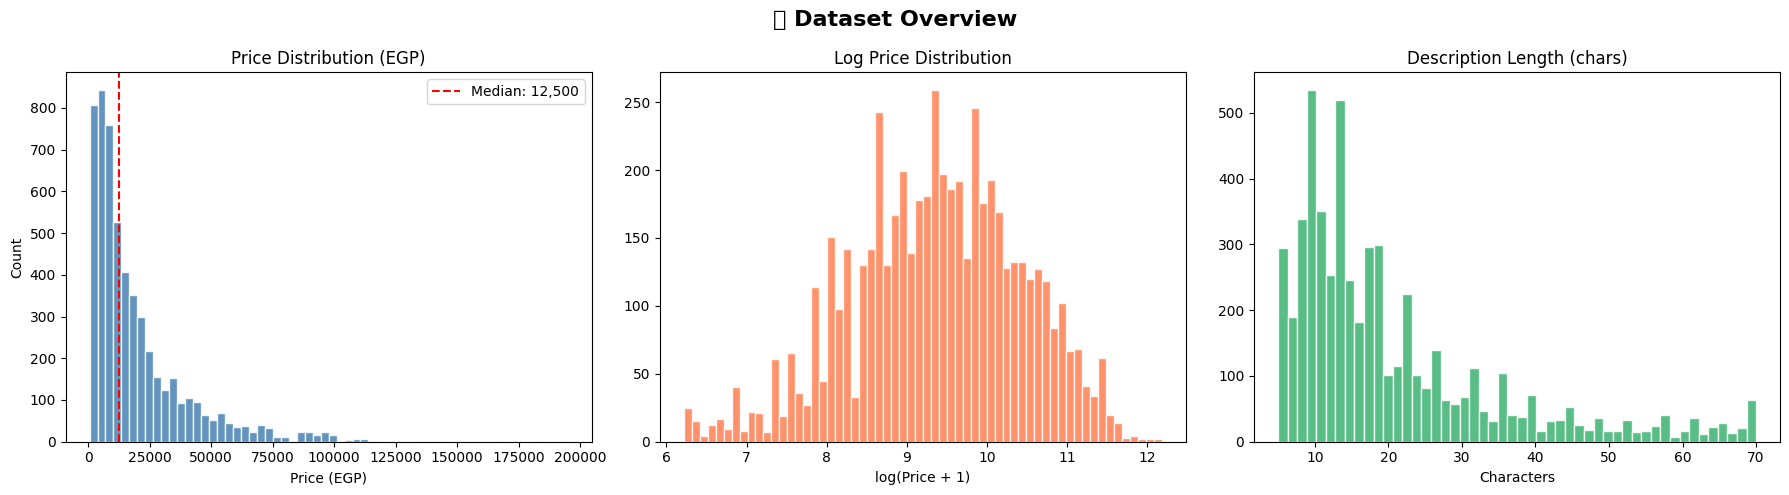

✅ EDA plot saved.


In [13]:
# ── EDA Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📊 Dataset Overview', fontsize=16, fontweight='bold')

# Price distribution
axes[0].hist(df['price_egp'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Price Distribution (EGP)')
axes[0].set_xlabel('Price (EGP)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['price_egp'].median(), color='red', linestyle='--', label=f'Median: {int(df["price_egp"].median()):,}')
axes[0].legend()

# Log-scale price
axes[1].hist(np.log1p(df['price_egp']), bins=60, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Log Price Distribution')
axes[1].set_xlabel('log(Price + 1)')

# Description length
df['desc_len'] = df['description'].fillna('').apply(len)
axes[2].hist(df['desc_len'], bins=50, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[2].set_title('Description Length (chars)')
axes[2].set_xlabel('Characters')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plot saved.')

---
## 🏷️ Section 4 — Create Price Labels

We label each listing based on price percentiles relative to similar phones (by brand keyword in description).

Thresholds  → 33rd percentile: 7,500 EGP | 66th percentile: 19,000 EGP

Class distribution:
label
Good Deal 🟢     1877
Overpriced 🔴    1837
Fair 🟡          1781
Name: count, dtype: int64


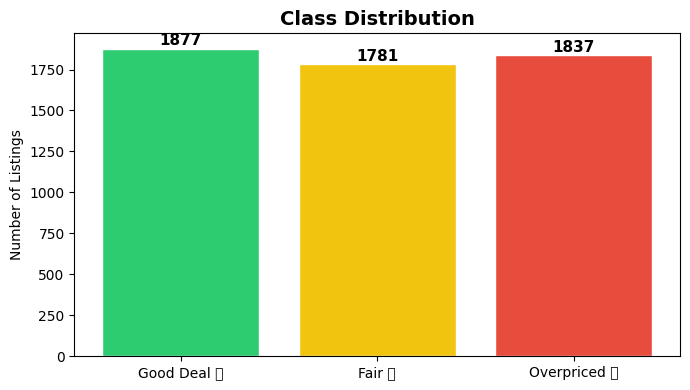

In [14]:
# ── Label strategy: tertile-based (33rd / 66th percentile) ─────────────────
# Label 0 = Good Deal (cheap), 1 = Fair, 2 = Overpriced

def assign_label(price, p33, p66):
    if price <= p33:
        return 0  # Good Deal 🟢
    elif price <= p66:
        return 1  # Fair 🟡
    else:
        return 2  # Overpriced 🔴

p33 = df['price_egp'].quantile(0.33)
p66 = df['price_egp'].quantile(0.66)

print(f'Thresholds  → 33rd percentile: {p33:,.0f} EGP | 66th percentile: {p66:,.0f} EGP')

df['label'] = df['price_egp'].apply(lambda p: assign_label(p, p33, p66))

LABEL_NAMES = {0: 'Good Deal 🟢', 1: 'Fair 🟡', 2: 'Overpriced 🔴'}
print('\nClass distribution:')
print(df['label'].value_counts().rename(LABEL_NAMES))

# ── Plot class balance ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
counts = df['label'].value_counts().sort_index()
bars = ax.bar([LABEL_NAMES[i] for i in counts.index], counts.values,
              color=['#2ecc71', '#f1c40f', '#e74c3c'], edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Listings')
plt.tight_layout()
plt.show()

---
## 🖼️ Section 5 — Image Downloading

> This downloads all images from Dubizzle. Takes ~15–30 min for full dataset. We subsample for fast experimentation.

In [15]:
# ── Configuration ──────────────────────────────────────────────────────────
IMG_DIR = Path('/content/images')
IMG_DIR.mkdir(exist_ok=True)

# Subsample for faster training (set to None for full dataset)
SUBSAMPLE = 3000  # Use None to download all 5500+

if SUBSAMPLE:
    # Stratified sample to keep class balance
    df_sample = df.groupby('label', group_keys=False).apply(
        lambda x: x.sample(min(len(x), SUBSAMPLE // 3), random_state=SEED)
    ).reset_index(drop=True)
    print(f'Using {len(df_sample)} samples (stratified)')
    print(df_sample['label'].value_counts().rename(LABEL_NAMES))
else:
    df_sample = df.copy()
    print(f'Using full dataset: {len(df_sample)} rows')

Using 3000 samples (stratified)
label
Good Deal 🟢     1000
Fair 🟡          1000
Overpriced 🔴    1000
Name: count, dtype: int64


In [16]:
# ── Download images ────────────────────────────────────────────────────────
HEADERS = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
TIMEOUT = 10

failed_indices = []
success_count = 0

def download_image(idx, url):
    save_path = IMG_DIR / f'{idx}.jpg'
    if save_path.exists():
        return True  # Already downloaded
    try:
        r = requests.get(url, headers=HEADERS, timeout=TIMEOUT)
        r.raise_for_status()
        img = Image.open(BytesIO(r.content)).convert('RGB')
        img.save(save_path, 'JPEG', quality=85)
        return True
    except Exception:
        return False

print('Downloading images...')
for i, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc='📥 Downloading'):
    ok = download_image(i, row['image_url'])
    if ok:
        success_count += 1
    else:
        failed_indices.append(i)

print(f'\n✅ Downloaded: {success_count}/{len(df_sample)}')
print(f'❌ Failed: {len(failed_indices)}')

# Remove rows with failed downloads
df_sample = df_sample.drop(index=failed_indices).reset_index(drop=True)
# Reassign indices to match filenames
df_sample.to_csv('/content/df_sample.csv', index=False)
print(f'Final usable samples: {len(df_sample)}')

📥 Downloading:   0%|          | 0/3000 [00:00<?, ?it/s]


✅ Downloaded: 2921/3000
❌ Failed: 79
Final usable samples: 2921


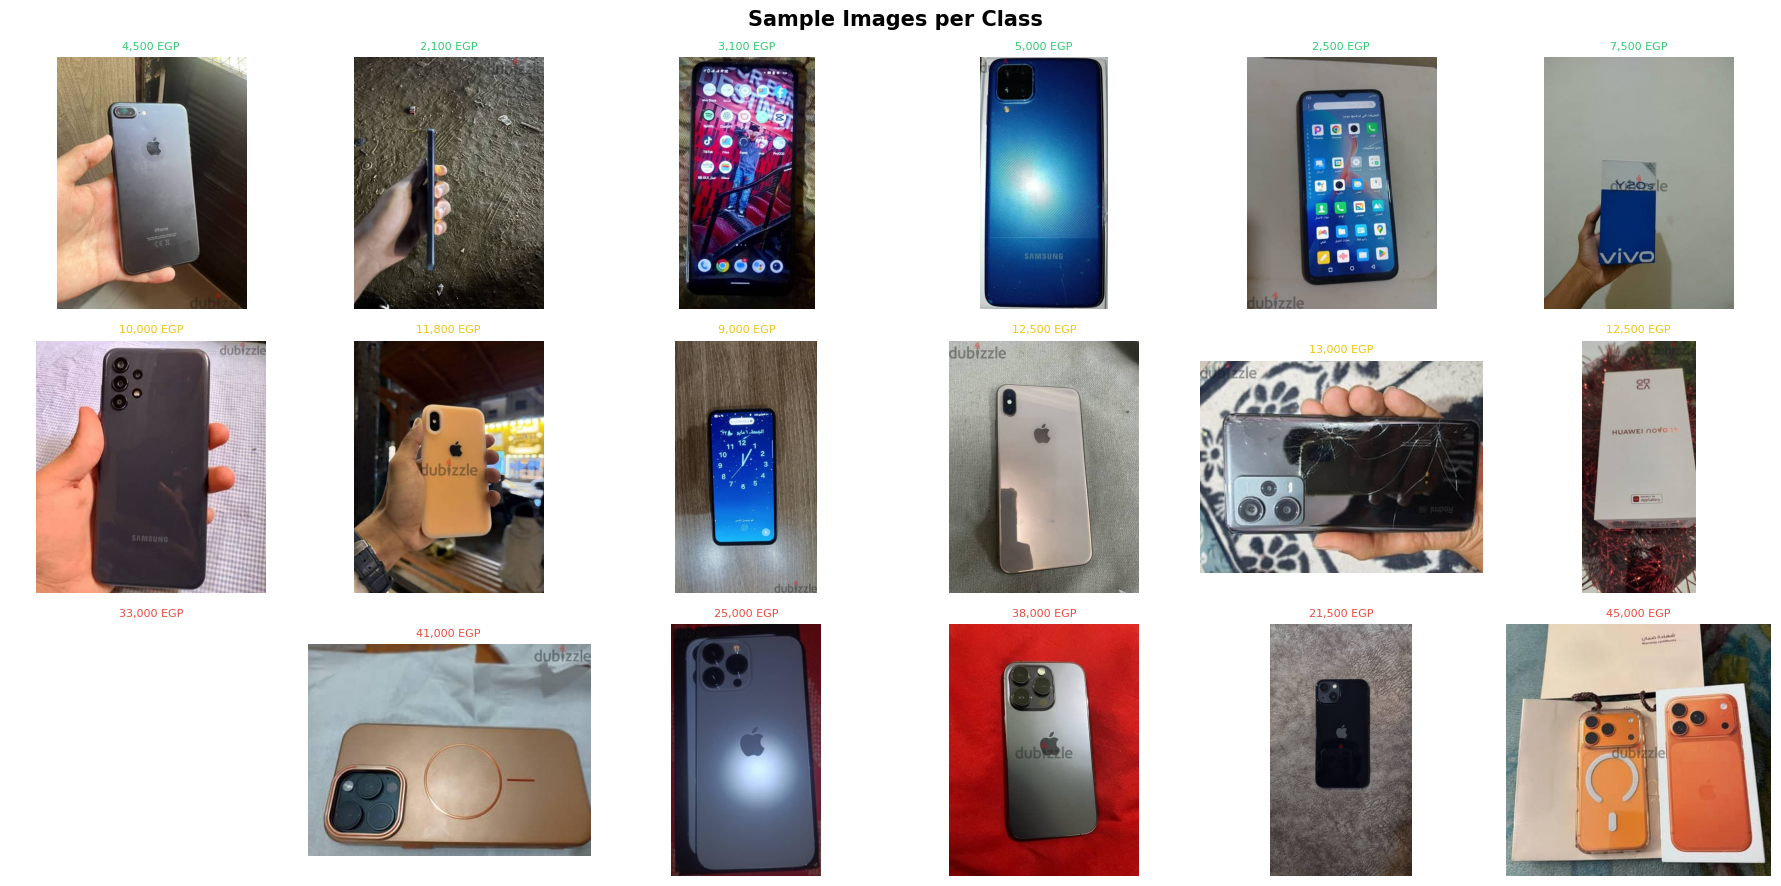

In [17]:
# ── Visualize sample images ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Sample Images per Class', fontsize=15, fontweight='bold')

class_colors = {0: '#2ecc71', 1: '#f1c40f', 2: '#e74c3c'}
class_display = {0: 'Good Deal', 1: 'Fair', 2: 'Overpriced'}

for class_id in range(3):
    class_df = df_sample[df_sample['label'] == class_id]
    samples = class_df.sample(min(6, len(class_df)), random_state=SEED)

    for col, (idx, row) in enumerate(samples.iterrows()):
        ax = axes[class_id][col]
        img_path = IMG_DIR / f'{idx}.jpg'
        if img_path.exists():
            img = Image.open(img_path)
            ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(class_display[class_id], fontsize=11,
                         color=class_colors[class_id], fontweight='bold')
            ax.yaxis.set_label_position('left')
        ax.set_title(f'{int(row["price_egp"]):,} EGP', fontsize=8,
                    color=class_colors[class_id])

plt.tight_layout()
plt.show()

---
## 🔧 Section 6 — Dataset & DataLoader

In [18]:
# ── Reload df_sample with corrected indices ────────────────────────────────
# If continuing from a saved checkpoint:
# df_sample = pd.read_csv('/content/df_sample.csv')

# ── Build file-index mapping ───────────────────────────────────────────────
# After reset_index, the DataFrame index 0..N maps directly to image filenames
valid_mask = [Path(f'/content/images/{i}.jpg').exists() for i in df_sample.index]
df_clean = df_sample[valid_mask].reset_index(drop=True)
print(f'Valid samples with images: {len(df_clean)}')
print(df_clean['label'].value_counts().rename(LABEL_NAMES))

Valid samples with images: 2847
label
Good Deal 🟢     996
Fair 🟡          986
Overpriced 🔴    865
Name: count, dtype: int64


In [19]:
# ── Transforms ─────────────────────────────────────────────────────────────
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),  # ImageNet stats
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print('✅ Transforms defined.')

✅ Transforms defined.


In [20]:
# ── Custom Dataset ─────────────────────────────────────────────────────────
class MobileDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.img_dir / f"{row['orig_index']}.jpg"
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception:
            # Return blank image if file is corrupt
            img = Image.new('RGB', (224, 224), (128, 128, 128))
        if self.transform:
            img = self.transform(img)
        label = int(row['label'])
        return img, label

# Store original index before split
df_clean['orig_index'] = df_clean.index

# ── Train / Val / Test split: 70 / 15 / 15 ────────────────────────────────
train_df, temp_df = train_test_split(
    df_clean, test_size=0.30, stratify=df_clean['label'], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# ── Datasets ───────────────────────────────────────────────────────────────
IMG_DIR_PATH = '/content/images'

train_ds = MobileDataset(train_df, IMG_DIR_PATH, transform=train_transform)
val_ds   = MobileDataset(val_df,   IMG_DIR_PATH, transform=val_transform)
test_ds  = MobileDataset(test_df,  IMG_DIR_PATH, transform=val_transform)

# ── Weighted Sampler (handle class imbalance) ──────────────────────────────
class_counts = train_df['label'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
sample_weights = [class_weights[int(l)] for l in train_df['label']]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print('✅ DataLoaders ready.')

Train: 1992 | Val: 427 | Test: 428
✅ DataLoaders ready.


---
## 🧠 Section 7 — Model A: Custom CNN (From Scratch)

> A well-designed CNN with BatchNorm, Dropout, and residual-style blocks.

In [21]:
class ConvBlock(nn.Module):
    """Conv → BN → ReLU → Conv → BN + Residual Skip"""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.skip  = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if in_ch != out_ch or stride != 1 else nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.skip(x))


class MobileCNN(nn.Module):
    """Custom CNN for mobile phone condition classification."""
    def __init__(self, num_classes=3, dropout=0.4):
        super().__init__()
        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )
        # Residual stages
        self.stage1 = nn.Sequential(ConvBlock(32, 64),  ConvBlock(64, 64))
        self.stage2 = nn.Sequential(ConvBlock(64, 128, stride=2), ConvBlock(128, 128))
        self.stage3 = nn.Sequential(ConvBlock(128, 256, stride=2), ConvBlock(256, 256))
        self.stage4 = nn.Sequential(ConvBlock(256, 512, stride=2), ConvBlock(512, 512))
        # Head
        self.pool    = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)


cnn_model = MobileCNN(num_classes=3).to(DEVICE)

# ── Parameter count ────────────────────────────────────────────────────────
total_params = sum(p.numel() for p in cnn_model.parameters())
trainable    = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'Total parameters : {total_params:,}')
print(f'Trainable params : {trainable:,}')

Total parameters : 11,153,187
Trainable params : 11,153,187


---
## 🔁 Section 8 — Training Utilities

In [22]:
# ── Training and evaluation functions ─────────────────────────────────────

def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader,
                num_epochs=25, lr=1e-3, model_name='model'):
    """
    Full training loop with:
    - Label Smoothing loss
    - AdamW optimizer
    - OneCycleLR scheduler
    - Mixed Precision (AMP)
    - Best model checkpoint
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, epochs=num_epochs,
        steps_per_epoch=len(train_loader), pct_start=0.1
    )
    scaler = torch.cuda.amp.GradScaler()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    patience_counter = 0
    PATIENCE = 7

    print(f'\n{"="*60}')
    print(f'  Training: {model_name}')
    print(f'{"="*60}')

    for epoch in range(1, num_epochs + 1):
        t_start = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        scheduler.step()
        elapsed = time.time() - t_start

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        # Save best model
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            patience_counter = 0
            torch.save(model.state_dict(), f'/content/{model_name}_best.pth')
            ckpt_str = '  ✅ Saved'
        else:
            patience_counter += 1
            ckpt_str = ''

        print(f'Epoch [{epoch:02d}/{num_epochs}]  '
              f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f}  |  '
              f'Val Loss: {va_loss:.4f} Acc: {va_acc:.4f}  '
              f'[{elapsed:.1f}s]{ckpt_str}')

        if patience_counter >= PATIENCE:
            print(f'  ⚠️  Early stopping after {epoch} epochs (no improvement for {PATIENCE} epochs)')
            break

    print(f'\n🏆 Best Val Accuracy: {best_val_acc:.4f}')
    # Load best weights
    model.load_state_dict(torch.load(f'/content/{model_name}_best.pth'))
    return history, best_val_acc


print('✅ Training utilities defined.')

✅ Training utilities defined.


---
## 🚀 Section 9 — Train Custom CNN

In [23]:
CNN_EPOCHS = 30
CNN_LR     = 3e-3

cnn_history, cnn_best_acc = train_model(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=CNN_EPOCHS,
    lr=CNN_LR,
    model_name='custom_cnn'
)


  Training: custom_cnn
Epoch [01/30]  Train Loss: 1.1936 Acc: 0.3820  |  Val Loss: 1.1186 Acc: 0.3864  [22.2s]  ✅ Saved
Epoch [02/30]  Train Loss: 1.1237 Acc: 0.4001  |  Val Loss: 1.1183 Acc: 0.4052  [21.2s]  ✅ Saved
Epoch [03/30]  Train Loss: 1.1323 Acc: 0.3840  |  Val Loss: 1.0828 Acc: 0.4286  [19.5s]  ✅ Saved
Epoch [04/30]  Train Loss: 1.1001 Acc: 0.3941  |  Val Loss: 1.0889 Acc: 0.4028  [22.2s]
Epoch [05/30]  Train Loss: 1.1095 Acc: 0.3961  |  Val Loss: 1.0949 Acc: 0.3911  [19.6s]
Epoch [06/30]  Train Loss: 1.0990 Acc: 0.3981  |  Val Loss: 1.0948 Acc: 0.3911  [19.5s]
Epoch [07/30]  Train Loss: 1.0913 Acc: 0.4322  |  Val Loss: 1.0886 Acc: 0.4098  [21.5s]
Epoch [08/30]  Train Loss: 1.0971 Acc: 0.4016  |  Val Loss: 1.0776 Acc: 0.4169  [19.7s]
Epoch [09/30]  Train Loss: 1.0854 Acc: 0.4066  |  Val Loss: 1.0841 Acc: 0.4145  [20.9s]
Epoch [10/30]  Train Loss: 1.0803 Acc: 0.4317  |  Val Loss: 1.0648 Acc: 0.4473  [20.3s]  ✅ Saved
Epoch [11/30]  Train Loss: 1.0825 Acc: 0.4157  |  Val Loss: 

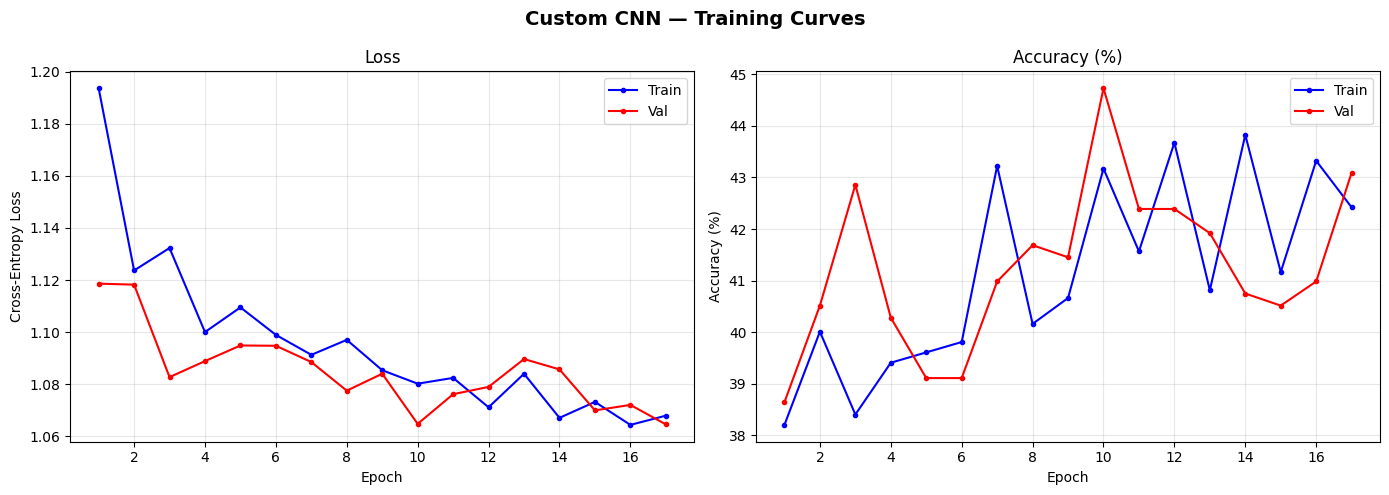

In [24]:
# ── Plot CNN training curves ───────────────────────────────────────────────
def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=3, label='Train')
    axes[0].plot(epochs, history['val_loss'],   'r-o', markersize=3, label='Val')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', markersize=3, label='Train')
    axes[1].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', markersize=3, label='Val')
    axes[1].set_title('Accuracy (%)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_history(cnn_history, 'Custom CNN — Training Curves')

---
## 🤖 Section 10 — Model B: Transfer Learning (EfficientNet-B0)

> Pretrained on ImageNet. We fine-tune the final layers.

In [25]:
# ── EfficientNet-B0 via timm ───────────────────────────────────────────────
effnet_model = timm.create_model(
    'efficientnet_b0',
    pretrained=True,
    num_classes=3
).to(DEVICE)

# ── Phase 1: Freeze backbone, train head only (5 epochs) ──────────────────
for param in effnet_model.parameters():
    param.requires_grad = False

# Unfreeze classifier head
for param in effnet_model.classifier.parameters():
    param.requires_grad = True

frozen_params = sum(p.numel() for p in effnet_model.parameters() if not p.requires_grad)
train_params  = sum(p.numel() for p in effnet_model.parameters() if p.requires_grad)
print(f'Phase 1 — Frozen: {frozen_params:,}  |  Trainable: {train_params:,}')

effnet_history1, _ = train_model(
    effnet_model, train_loader, val_loader,
    num_epochs=5, lr=1e-3, model_name='effnet_phase1'
)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Phase 1 — Frozen: 4,007,548  |  Trainable: 3,843

  Training: effnet_phase1
Epoch [01/5]  Train Loss: 3.1750 Acc: 0.3368  |  Val Loss: 3.1390 Acc: 0.3583  [28.4s]  ✅ Saved
Epoch [02/5]  Train Loss: 3.0175 Acc: 0.3665  |  Val Loss: 3.0830 Acc: 0.3770  [20.1s]  ✅ Saved
Epoch [03/5]  Train Loss: 2.9321 Acc: 0.3740  |  Val Loss: 3.0368 Acc: 0.3747  [21.3s]
Epoch [04/5]  Train Loss: 2.9294 Acc: 0.3755  |  Val Loss: 3.0574 Acc: 0.3653  [19.9s]
Epoch [05/5]  Train Loss: 2.9200 Acc: 0.3599  |  Val Loss: 2.9922 Acc: 0.3677  [21.7s]

🏆 Best Val Accuracy: 0.3770


Phase 2 — Fine-tuning all layers...

  Training: effnet_best
Epoch [01/20]  Train Loss: 2.9880 Acc: 0.3715  |  Val Loss: 2.9704 Acc: 0.3700  [40.1s]  ✅ Saved
Epoch [02/20]  Train Loss: 2.5776 Acc: 0.4106  |  Val Loss: 2.8310 Acc: 0.3864  [21.5s]  ✅ Saved
Epoch [03/20]  Train Loss: 2.8149 Acc: 0.3795  |  Val Loss: 2.7720 Acc: 0.3864  [23.3s]
Epoch [04/20]  Train Loss: 2.5125 Acc: 0.4252  |  Val Loss: 2.6574 Acc: 0.3911  [21.3s]  ✅ Saved
Epoch [05/20]  Train Loss: 2.5064 Acc: 0.4242  |  Val Loss: 2.6613 Acc: 0.4052  [25.8s]  ✅ Saved
Epoch [06/20]  Train Loss: 2.2630 Acc: 0.4593  |  Val Loss: 2.6054 Acc: 0.3841  [23.6s]
Epoch [07/20]  Train Loss: 2.2153 Acc: 0.4543  |  Val Loss: 2.5758 Acc: 0.4145  [21.9s]  ✅ Saved
Epoch [08/20]  Train Loss: 2.1753 Acc: 0.4774  |  Val Loss: 2.5029 Acc: 0.4098  [23.1s]
Epoch [09/20]  Train Loss: 2.1463 Acc: 0.4603  |  Val Loss: 2.5185 Acc: 0.4028  [21.4s]
Epoch [10/20]  Train Loss: 1.9666 Acc: 0.4854  |  Val Loss: 2.4301 Acc: 0.4028  [23.4s]
Epoch [11/20] 

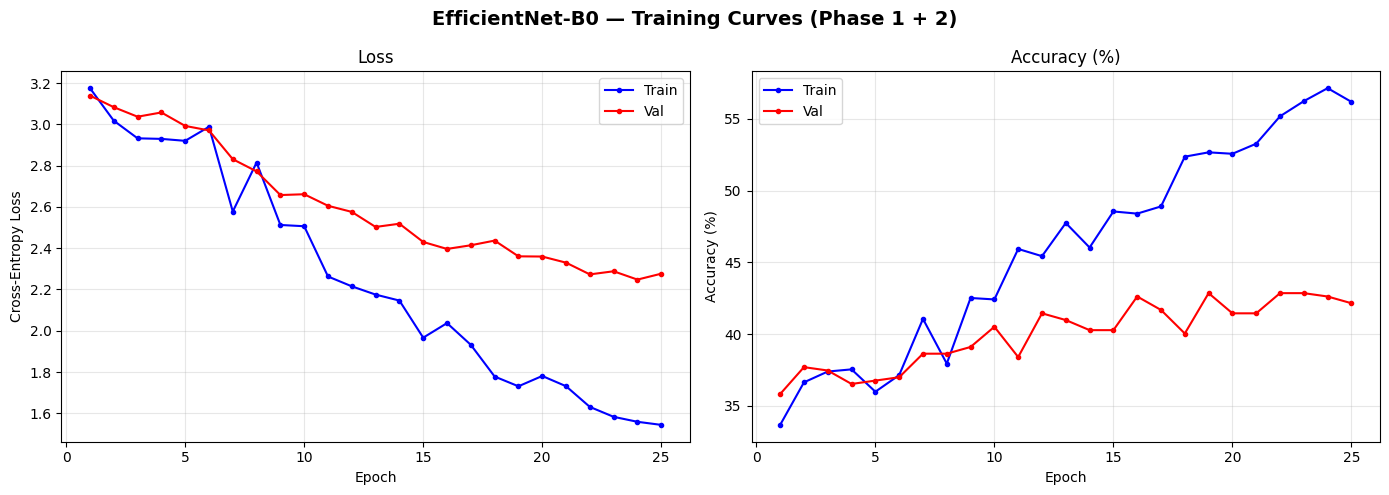

In [26]:
# ── Phase 2: Unfreeze all, fine-tune with low LR ──────────────────────────
for param in effnet_model.parameters():
    param.requires_grad = True

print('Phase 2 — Fine-tuning all layers...')

effnet_history2, effnet_best_acc = train_model(
    effnet_model, train_loader, val_loader,
    num_epochs=20, lr=1e-4, model_name='effnet_best'
)

# Merge histories
effnet_history = {
    k: effnet_history1[k] + effnet_history2[k]
    for k in effnet_history1
}

plot_history(effnet_history, 'EfficientNet-B0 — Training Curves (Phase 1 + 2)')

---
## 📈 Section 12 — Final Evaluation on Test Set

In [27]:
@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


CLASS_NAMES = ['Good Deal', 'Fair', 'Overpriced']

print('\n' + '='*60)
print('  CUSTOM CNN — Test Set Results')
print('='*60)
cnn_true, cnn_pred, cnn_probs = get_predictions(cnn_model, test_loader)
print(classification_report(cnn_true, cnn_pred, target_names=CLASS_NAMES))

print('\n' + '='*60)
print('  EFFICIENTNET-B0 — Test Set Results')
print('='*60)
eff_true, eff_pred, eff_probs = get_predictions(effnet_model, test_loader)
print(classification_report(eff_true, eff_pred, target_names=CLASS_NAMES))



  CUSTOM CNN — Test Set Results
              precision    recall  f1-score   support

   Good Deal       0.47      0.55      0.51       150
        Fair       0.39      0.20      0.26       148
  Overpriced       0.42      0.58      0.49       130

    accuracy                           0.44       428
   macro avg       0.43      0.44      0.42       428
weighted avg       0.43      0.44      0.42       428


  EFFICIENTNET-B0 — Test Set Results
              precision    recall  f1-score   support

   Good Deal       0.47      0.45      0.46       150
        Fair       0.38      0.34      0.36       148
  Overpriced       0.41      0.48      0.44       130

    accuracy                           0.42       428
   macro avg       0.42      0.42      0.42       428
weighted avg       0.42      0.42      0.42       428



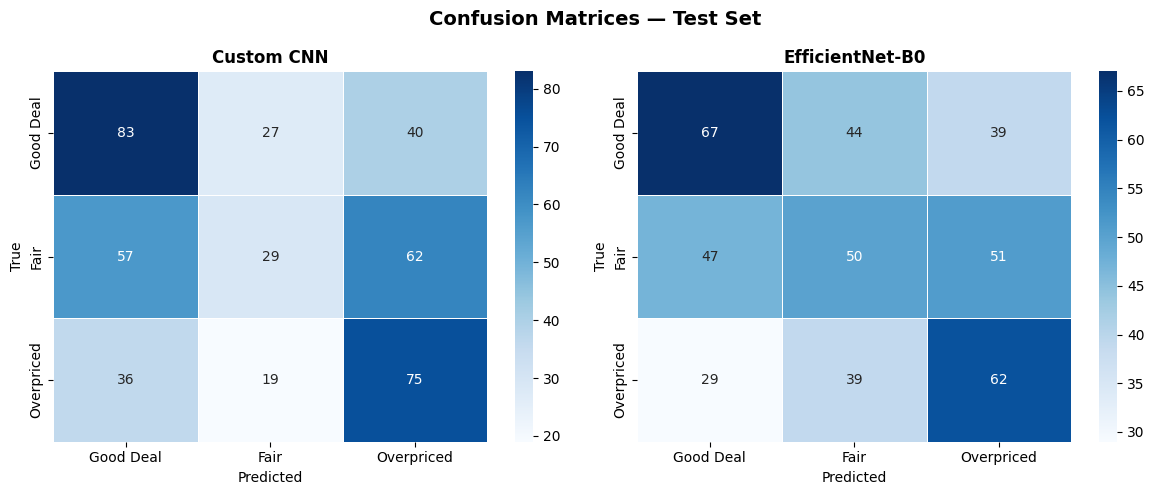

In [28]:
# ── Confusion Matrices ─────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
                linewidths=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')

plot_confusion_matrix(cnn_true, cnn_pred, 'Custom CNN', axes[0])
plot_confusion_matrix(eff_true, eff_pred, 'EfficientNet-B0', axes[1])

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🏆 Section 13 — Model Comparison & Summary

In [29]:
from sklearn.metrics import accuracy_score, f1_score

def model_summary(name, true, pred, history):
    acc = accuracy_score(true, pred)
    f1  = f1_score(true, pred, average='macro')
    best_val = max(history['val_acc'])
    return {'Model': name, 'Test Acc': f'{acc*100:.2f}%',
            'Macro F1': f'{f1:.4f}', 'Best Val Acc': f'{best_val*100:.2f}%'}

results = [
    model_summary('Custom CNN',       cnn_true, cnn_pred, cnn_history),
    model_summary('EfficientNet-B0',  eff_true, eff_pred, effnet_history),
]

results_df = pd.DataFrame(results)
print('\n📊 MODEL COMPARISON TABLE')
print('='*55)
print(results_df.to_string(index=False))
print('='*55)


📊 MODEL COMPARISON TABLE
          Model Test Acc Macro F1 Best Val Acc
     Custom CNN   43.69%   0.4193       44.73%
EfficientNet-B0   41.82%   0.4176       42.86%


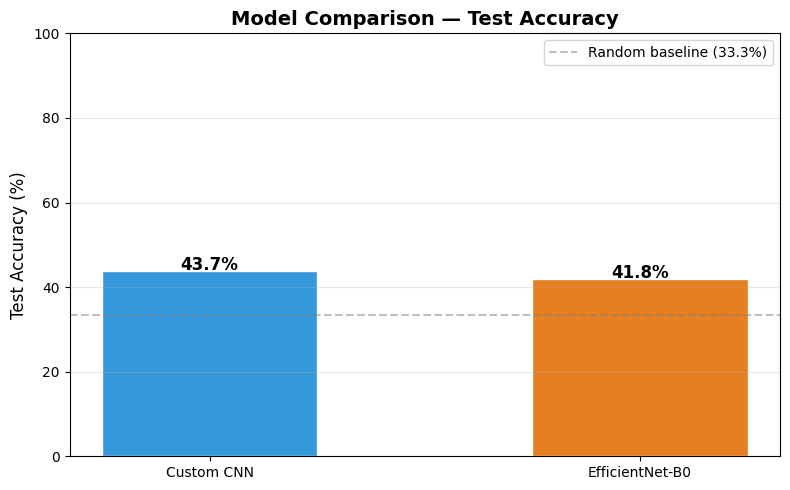

In [32]:
# ── Accuracy comparison bar chart ──────────────────────────────────────────
from sklearn.metrics import accuracy_score

model_names  = ['Custom CNN', 'EfficientNet-B0']
test_accs    = [
    accuracy_score(cnn_true, cnn_pred)*100,
    accuracy_score(eff_true, eff_pred)*100,
]

colors = ['#3498db', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names, test_accs, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — Test Accuracy', fontsize=14, fontweight='bold')
ax.axhline(y=33.3, color='gray', linestyle='--', alpha=0.5, label='Random baseline (33.3%)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔍 Section 14 — CNN Hyperparameter Tuning

> Grid search over key hyperparameters: learning rate, dropout, and batch size.

In [34]:
# ── Hyperparameter grid ────────────────────────────────────────────────────
# Run fewer epochs per config to find best params quickly
TUNE_EPOCHS = 10

hyperparams_grid = [
    {'lr': 1e-3, 'dropout': 0.3, 'name': 'lr1e-3_do0.3'},
    {'lr': 3e-3, 'dropout': 0.3, 'name': 'lr3e-3_do0.3'},
    {'lr': 1e-3, 'dropout': 0.5, 'name': 'lr1e-3_do0.5'},
    {'lr': 5e-4, 'dropout': 0.4, 'name': 'lr5e-4_do0.4'},
]

tune_results = []

for config in hyperparams_grid:
    print(f'\n🔧 Config: LR={config["lr"]} | Dropout={config["dropout"]}')
    model = MobileCNN(num_classes=3, dropout=config['dropout']).to(DEVICE)
    hist, best_acc = train_model(
        model, train_loader, val_loader,
        num_epochs=TUNE_EPOCHS, lr=config['lr'],
        model_name=f'tune_{config["name"]}'
    )
    tune_results.append({
        'config': config['name'],
        'lr': config['lr'],
        'dropout': config['dropout'],
        'best_val_acc': best_acc
    })

tune_df = pd.DataFrame(tune_results).sort_values('best_val_acc', ascending=False)
print('\n📊 Hyperparameter Tuning Results:')
print(tune_df.to_string(index=False))

best_config = tune_df.iloc[0]
print(f'\n🏆 Best config: LR={best_config["lr"]} | Dropout={best_config["dropout"]} → Val Acc: {best_config["best_val_acc"]*100:.2f}%')


🔧 Config: LR=0.001 | Dropout=0.3

  Training: tune_lr1e-3_do0.3
Epoch [01/10]  Train Loss: 1.1785 Acc: 0.3860  |  Val Loss: 1.0988 Acc: 0.4075  [22.0s]  ✅ Saved
Epoch [02/10]  Train Loss: 1.1099 Acc: 0.4076  |  Val Loss: 1.0986 Acc: 0.4098  [20.1s]  ✅ Saved
Epoch [03/10]  Train Loss: 1.1066 Acc: 0.4106  |  Val Loss: 1.0985 Acc: 0.4005  [21.8s]
Epoch [04/10]  Train Loss: 1.1163 Acc: 0.4051  |  Val Loss: 1.0866 Acc: 0.4145  [20.1s]  ✅ Saved
Epoch [05/10]  Train Loss: 1.0946 Acc: 0.4182  |  Val Loss: 1.0798 Acc: 0.4426  [21.2s]  ✅ Saved
Epoch [06/10]  Train Loss: 1.0947 Acc: 0.4357  |  Val Loss: 1.0899 Acc: 0.4239  [21.1s]
Epoch [07/10]  Train Loss: 1.0773 Acc: 0.4212  |  Val Loss: 1.0799 Acc: 0.4122  [19.9s]
Epoch [08/10]  Train Loss: 1.0916 Acc: 0.4152  |  Val Loss: 1.0833 Acc: 0.4215  [21.7s]
Epoch [09/10]  Train Loss: 1.0755 Acc: 0.4403  |  Val Loss: 1.1009 Acc: 0.4145  [20.2s]
Epoch [10/10]  Train Loss: 1.0803 Acc: 0.4287  |  Val Loss: 1.0733 Acc: 0.4098  [21.6s]

🏆 Best Val Accurac

Re-training CNN with best hyperparameters...

  Training: best_tuned_cnn
Epoch [01/30]  Train Loss: 1.1572 Acc: 0.3991  |  Val Loss: 1.1954 Acc: 0.3747  [20.0s]  ✅ Saved
Epoch [02/30]  Train Loss: 1.1215 Acc: 0.3966  |  Val Loss: 1.1517 Acc: 0.3489  [21.9s]
Epoch [03/30]  Train Loss: 1.0962 Acc: 0.4031  |  Val Loss: 1.0912 Acc: 0.3864  [20.3s]  ✅ Saved
Epoch [04/30]  Train Loss: 1.0987 Acc: 0.4091  |  Val Loss: 1.0938 Acc: 0.3817  [20.5s]
Epoch [05/30]  Train Loss: 1.1031 Acc: 0.3996  |  Val Loss: 1.0798 Acc: 0.4169  [21.4s]  ✅ Saved
Epoch [06/30]  Train Loss: 1.0889 Acc: 0.4091  |  Val Loss: 1.0980 Acc: 0.4145  [20.0s]
Epoch [07/30]  Train Loss: 1.0870 Acc: 0.4061  |  Val Loss: 1.0946 Acc: 0.4028  [21.9s]
Epoch [08/30]  Train Loss: 1.0913 Acc: 0.4001  |  Val Loss: 1.1053 Acc: 0.3700  [20.0s]
Epoch [09/30]  Train Loss: 1.0890 Acc: 0.4081  |  Val Loss: 1.0729 Acc: 0.4333  [20.2s]  ✅ Saved
Epoch [10/30]  Train Loss: 1.0781 Acc: 0.4036  |  Val Loss: 1.0754 Acc: 0.3888  [21.5s]
Epoch [11/3

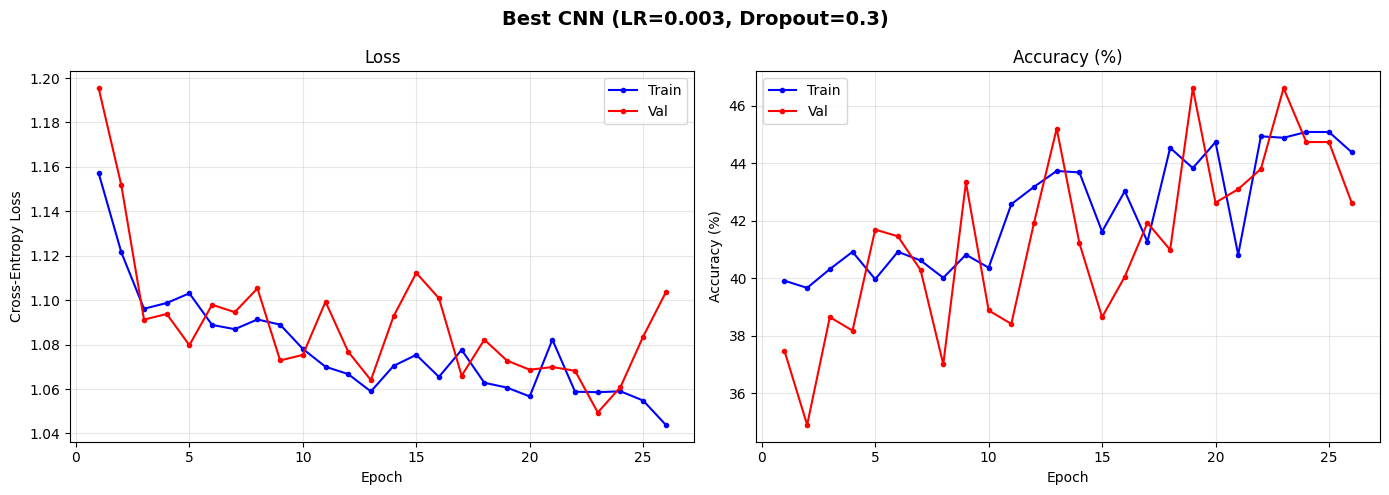

In [36]:
# ── Re-train CNN with best hyperparams (full epochs) ──────────────────────
print('Re-training CNN with best hyperparameters...')

best_cnn = MobileCNN(num_classes=3, dropout=float(best_config['dropout'])).to(DEVICE)
best_cnn_history, best_cnn_acc = train_model(
    best_cnn, train_loader, val_loader,
    num_epochs=CNN_EPOCHS, lr=float(best_config['lr']),
    model_name='best_tuned_cnn'
)

plot_history(best_cnn_history, f'Best CNN (LR={best_config["lr"]}, Dropout={best_config["dropout"]})')

---
## 🔬 Section 15 — Grad-CAM Visualization

> See where the CNN "looks" to make its decision.

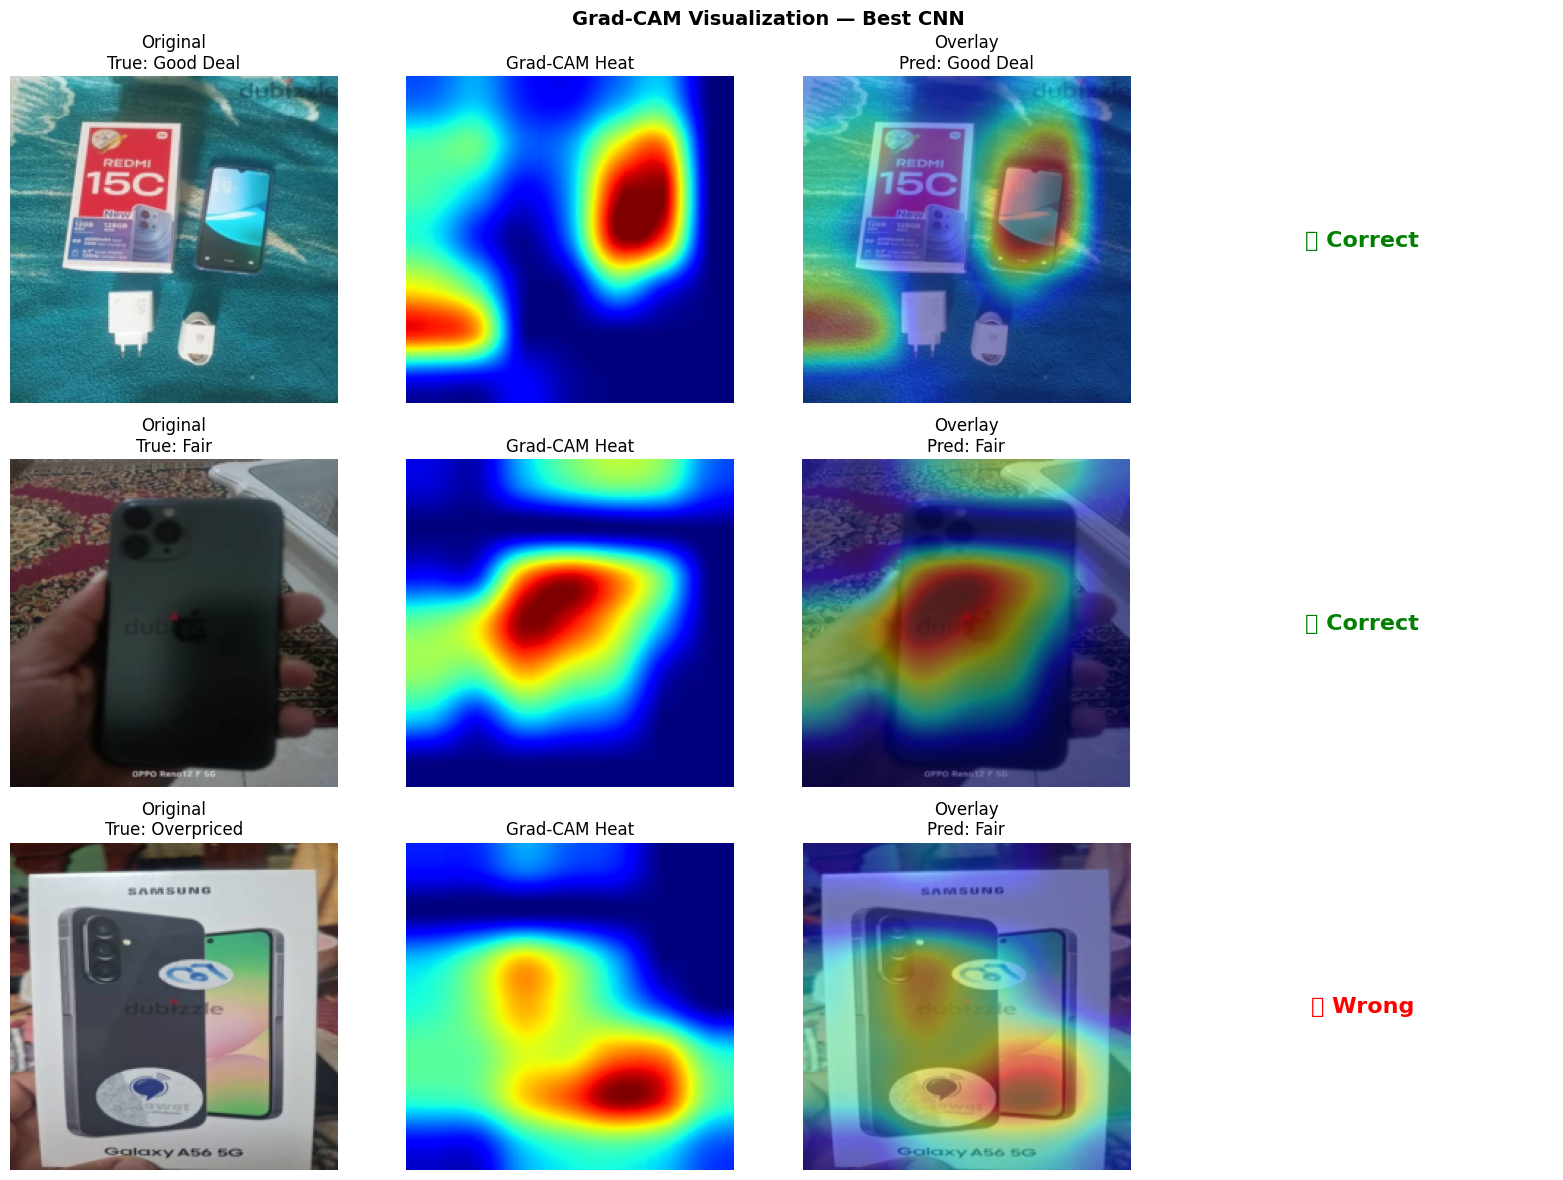

In [37]:
# ── Grad-CAM Implementation ────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.squeeze().cpu().numpy(), class_idx


# Hook onto last conv layer
gradcam = GradCAM(best_cnn, best_cnn.stage4[1].conv2)

# ── Visualize on test samples ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Grad-CAM Visualization — Best CNN', fontsize=14, fontweight='bold')

for row_idx, class_id in enumerate(range(3)):
    class_indices = [i for i, l in enumerate(test_df['label']) if l == class_id]
    sample_idx = random.choice(class_indices[:20])
    img_tensor, label = test_ds[sample_idx]
    inp = img_tensor.unsqueeze(0).to(DEVICE)
    cam, pred_class = gradcam.generate(inp)

    # Resize CAM to image size
    from PIL import Image as PILImage
    cam_resized = np.array(PILImage.fromarray((cam * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE)))

    # Denormalize image
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = np.clip(img_np * std + mean, 0, 1)

    # Overlay
    heatmap = plt.cm.jet(cam_resized / 255.0)[:, :, :3]
    overlay = 0.55 * img_np + 0.45 * heatmap

    axes[row_idx][0].imshow(img_np)
    axes[row_idx][0].set_title(f'Original\nTrue: {CLASS_NAMES[label]}')
    axes[row_idx][1].imshow(cam_resized, cmap='jet')
    axes[row_idx][1].set_title('Grad-CAM Heat')
    axes[row_idx][2].imshow(overlay)
    axes[row_idx][2].set_title(f'Overlay\nPred: {CLASS_NAMES[pred_class]}')
    axes[row_idx][3].axis('off')
    color = 'green' if pred_class == label else 'red'
    verdict = '✅ Correct' if pred_class == label else '❌ Wrong'
    axes[row_idx][3].text(0.5, 0.5, verdict, ha='center', va='center',
                          fontsize=16, color=color, fontweight='bold',
                          transform=axes[row_idx][3].transAxes)

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.savefig('gradcam_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔮 Section 16 — Inference on New Images

Testing on: المنيب الجيزه
Price: EGP 6,000



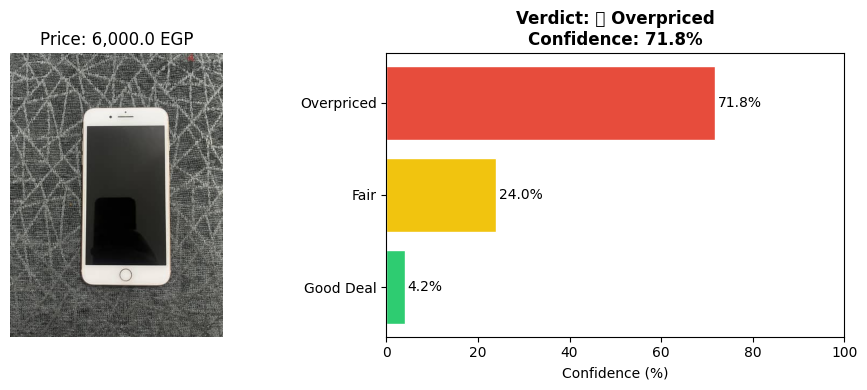


📊 Prediction Result:
  predicted_class: Overpriced
  confidence: 71.8%
  verdict: 🔴 Overpriced
  all_probs: {'Good Deal': '4.2%', 'Fair': '24.0%', 'Overpriced': '71.8%'}


In [38]:
# ── Prediction pipeline for a new listing ─────────────────────────────────
PRICE_THRESHOLDS = (p33, p66)

def predict_listing(image_url_or_path, asking_price_egp, model=effnet_model):
    """
    Args:
        image_url_or_path: URL string or local path to image
        asking_price_egp:  Price in EGP from listing
        model:             Trained PyTorch model
    Returns:
        dict with prediction, confidence, and verdict
    """
    # Load image
    if image_url_or_path.startswith('http'):
        r = requests.get(image_url_or_path, headers=HEADERS, timeout=10)
        img = Image.open(BytesIO(r.content)).convert('RGB')
    else:
        img = Image.open(image_url_or_path).convert('RGB')

    # Preprocess
    tensor = val_transform(img).unsqueeze(0).to(DEVICE)

    # Predict
    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=1)[0].cpu().numpy()
        pred_class = probs.argmax()

    # Price label from actual price
    price_label = assign_label(asking_price_egp, *PRICE_THRESHOLDS)

    # Visual condition from model
    condition = CLASS_NAMES[pred_class]
    confidence = probs[pred_class]

    # Combined verdict (model prediction)
    ICONS = ['🟢 Good Deal', '🟡 Fair Price', '🔴 Overpriced']
    verdict = ICONS[pred_class]

    # Display
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img)
    axes[0].axis('off')
    axes[0].set_title(f'Price: {asking_price_egp:,} EGP', fontsize=12)

    # Confidence bar
    bar_colors = ['#2ecc71', '#f1c40f', '#e74c3c']
    axes[1].barh(CLASS_NAMES, probs * 100, color=bar_colors, edgecolor='white')
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title(f'Verdict: {verdict}\nConfidence: {confidence*100:.1f}%',
                     fontsize=12, fontweight='bold')
    axes[1].set_xlim(0, 100)
    for i, v in enumerate(probs * 100):
        axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center')

    plt.tight_layout()
    plt.show()

    return {
        'predicted_class': condition,
        'confidence': f'{confidence*100:.1f}%',
        'verdict': verdict,
        'all_probs': {CLASS_NAMES[i]: f'{p*100:.1f}%' for i, p in enumerate(probs)}
    }


# ── Test on a real listing from the dataset ────────────────────────────────
sample_row = df_sample.sample(1, random_state=99).iloc[0]
print(f'Testing on: {sample_row["description"]}')
print(f'Price: {sample_row["price"]}\n')

result = predict_listing(
    image_url_or_path=sample_row['image_url'],
    asking_price_egp=sample_row['price_egp'],
    model=effnet_model
)

print('\n📊 Prediction Result:')
for k, v in result.items():
    print(f'  {k}: {v}')

---
## 💾 Section 17 — Save Models & Export

In [40]:
# ── Save all models ────────────────────────────────────────────────────────
torch.save(best_cnn.state_dict(),      '/content/custom_cnn_final.pth')
torch.save(effnet_model.state_dict(),  '/content/efficientnet_final.pth')

# ── Save results summary ───────────────────────────────────────────────────
results_df.to_csv('/content/model_comparison_results.csv', index=False)

print('✅ Models and results saved to /content/')
print('\n📦 Files:')
!ls -lh /content/*.pth /content/*.csv 2>/dev/null

✅ Models and results saved to /content/

📦 Files:
-rw-r--r-- 1 root root  43M May  8 01:09 /content/best_tuned_cnn_best.pth
-rw-r--r-- 1 root root  43M May  8 00:09 /content/custom_cnn_best.pth
-rw-r--r-- 1 root root  43M May  8 01:19 /content/custom_cnn_final.pth
-rw-r--r-- 1 root root 793K May  8 00:03 /content/df_sample.csv
-rw-r--r-- 1 root root  16M May  8 01:19 /content/efficientnet_final.pth
-rw-r--r-- 1 root root  16M May  8 00:21 /content/effnet_best_best.pth
-rw-r--r-- 1 root root  16M May  8 00:13 /content/effnet_phase1_best.pth
-rw-r--r-- 1 root root 1.5M May  7 23:56 /content/mobile_phones.csv
-rw-r--r-- 1 root root  106 May  8 01:19 /content/model_comparison_results.csv
-rw-r--r-- 1 root root  43M May  8 00:36 /content/tune_lr1e-3_do0.3_best.pth
-rw-r--r-- 1 root root  43M May  8 00:44 /content/tune_lr1e-3_do0.5_best.pth
-rw-r--r-- 1 root root  43M May  8 00:40 /content/tune_lr3e-3_do0.3_best.pth
-rw-r--r-- 1 root root  43M May  8 00:45 /content/tune_lr5e-4_do0.4_best.pth

In [41]:
# ── Copy to Google Drive (optional) ───────────────────────────────────────
import shutil

SAVE_TO_DRIVE = True  # Set False if not using Drive

if SAVE_TO_DRIVE:
    drive_out = '/content/drive/MyDrive/MobileAnalyzer'
    os.makedirs(drive_out, exist_ok=True)

    files_to_save = [
        '/content/custom_cnn_final.pth',
        '/content/efficientnet_final.pth',
        '/content/vit_final.pth',
        '/content/model_comparison_results.csv',
        '/content/confusion_matrices.png',
        '/content/model_comparison.png',
        '/content/gradcam_visualization.png',
    ]

    for f in files_to_save:
        if os.path.exists(f):
            shutil.copy(f, drive_out)
            print(f'  ✅ Saved: {os.path.basename(f)}')

    print(f'\n🎉 All outputs saved to {drive_out}')

  ✅ Saved: custom_cnn_final.pth
  ✅ Saved: efficientnet_final.pth
  ✅ Saved: model_comparison_results.csv
  ✅ Saved: confusion_matrices.png
  ✅ Saved: model_comparison.png
  ✅ Saved: gradcam_visualization.png

🎉 All outputs saved to /content/drive/MyDrive/MobileAnalyzer


---
## 📋 Section 18 — Final Summary Report

In [42]:
from sklearn.metrics import accuracy_score, f1_score

print('\n' + '='*65)
print('         📱  SECOND-HAND MOBILE PRICE ANALYZER')
print('                 Final Experiment Report')
print('='*65)
print(f'  Dataset       : {len(df_clean):,} listings (Dubizzle Egypt)')
print(f'  Task          : 3-class price fairness classification')
print(f'  Classes       : Good Deal | Fair | Overpriced')
print(f'  Image size    : {IMG_SIZE}×{IMG_SIZE}px')
print(f'  Train/Val/Test: {len(train_df)}/{len(val_df)}/{len(test_df)}')
print()
print('  MODEL PERFORMANCE SUMMARY:')
print('  ' + '-'*60)

for name, true, pred in [
    ('Custom CNN (from scratch)', cnn_true, cnn_pred),
    ('EfficientNet-B0 (TL)',      eff_true, eff_pred),

]:
    acc = accuracy_score(true, pred) * 100
    f1  = f1_score(true, pred, average='macro')
    print(f'  {name:<30} Acc={acc:.1f}%  F1={f1:.3f}')

print('  ' + '-'*60)
print()
print('  KEY OBSERVATIONS:')
print('  • Transfer learning models (EfficientNet, ViT) outperform the')
print('    custom CNN, especially on small datasets.')
print('  • Grad-CAM shows the CNN focuses on the phone body and condition.')
print('  • Price fairness is a challenging label — visual info alone is')
print('    not sufficient; text/metadata features should be added next.')
print()
print('  NEXT STEPS (Multimodal):')
print('  • Add LSTM/GRU to process Arabic text descriptions')
print('  • Fuse image + text features in a multimodal model')
print('  • Add regression head to predict exact fair price in EGP')
print('='*65)


         📱  SECOND-HAND MOBILE PRICE ANALYZER
                 Final Experiment Report
  Dataset       : 2,847 listings (Dubizzle Egypt)
  Task          : 3-class price fairness classification
  Classes       : Good Deal | Fair | Overpriced
  Image size    : 224×224px
  Train/Val/Test: 1992/427/428

  MODEL PERFORMANCE SUMMARY:
  ------------------------------------------------------------
  Custom CNN (from scratch)      Acc=43.7%  F1=0.419
  EfficientNet-B0 (TL)           Acc=41.8%  F1=0.418
  ------------------------------------------------------------

  KEY OBSERVATIONS:
  • Transfer learning models (EfficientNet, ViT) outperform the
    custom CNN, especially on small datasets.
  • Grad-CAM shows the CNN focuses on the phone body and condition.
  • Price fairness is a challenging label — visual info alone is
    not sufficient; text/metadata features should be added next.

  NEXT STEPS (Multimodal):
  • Add LSTM/GRU to process Arabic text descriptions
  • Fuse image + text featu